In [ ]:
!pip install datasets transformers langdetect

In [ ]:
import pandas as pd
import torch
import numpy as np
import re
import time
import random
import datetime
import matplotlib.pyplot as plt
from langdetect import detect, DetectorFactory, LangDetectException
from torch import nn
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tqdm import tqdm
from bs4 import BeautifulSoup
from datasets import Dataset, DatasetDict
from google.colab import drive
from torch.utils.data import Dataset, DataLoader, random_split, RandomSampler, SequentialSampler
from transformers import GPT2Tokenizer, GPT2LMHeadModel, GPT2Config, get_linear_schedule_with_warmup, StoppingCriteria, StoppingCriteriaList, pipeline

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load train and test CSV files.
df_train = pd.read_csv('/content/drive/My Drive/Colab Notebooks/job_data_files/salary_labelled_development_set.csv')
df_test = pd.read_csv('/content/drive/My Drive/Colab Notebooks/job_data_files/salary_labelled_test_set.csv')

# Define a helper function to remove HTML tags from text.
def clean_html(text):
    if pd.isnull(text):
        return ""
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text(separator=" ", strip=True)

# Clean job_ad_details and create a new column
df_train['job_ad_details_clean'] = df_train['job_ad_details'].apply(clean_html)
df_test['job_ad_details_clean'] = df_test['job_ad_details'].apply(clean_html)

print(df_train['job_ad_details_clean'].head())

0    Job Opening Financial Account - Call Center Ag...
1    Job Opening Aspiring Call Center Agents - Work...
2    Original Foods Baking Co. is one of New Zealan...
3    The Payer Analyst individual is assigned to th...
4    The DLA Piper team operates across more than 4...
Name: job_ad_details_clean, dtype: object


In [ ]:
df_train, df_val = train_test_split(df_train, test_size=0.1, random_state=42)

df_train['input_text'] = (
    "Job Title: (" + df_train['job_title'].fillna('') + ") " +
    "Job Ad Details: (" + df_train['job_ad_details_clean'].fillna('') + " " +
    "Nation Short Desc: (" + df_train['nation_short_desc'].fillna('') + ") " +
    "Salary Additional Text: (" + df_train['salary_additional_text'].fillna('') + ") " +
    "Salary: (" + df_train['y_true'] + ")"
)


df_val['input_text'] = (
    "Job Title: (" + df_val['job_title'].fillna('') + ") " +
    "Job Ad Details: (" + df_val['job_ad_details_clean'].fillna('') + ") " +
    "Nation Short Desc: (" + df_val['nation_short_desc'].fillna('') + ") " +
    "Salary Additional Text: (" + df_val['salary_additional_text'].fillna('') + ") " +
    "Salary: ("
)


df_test['input_text'] = (
    "Job Title: (" + df_test['job_title'].fillna('') + ") " +
    "Job Ad Details: (" + df_test['job_ad_details_clean'].fillna('') + ") " +
    "Nation Short Desc: (" + df_test['nation_short_desc'].fillna('') + ") " +
    "Salary Additional Text: (" + df_test['salary_additional_text'].fillna('') + ") " +
    "Salary: ("
)

# Show a preview of the cleaned data
print(df_train['input_text'].head())

1523    Job Title: (Rare Disease Specialist Makassar) ...
1361    Job Title: (保健員) Job Ad Details: (北角小型院舍誠聘日更保健...
1508    Job Title: (HR Admin (Work Pass Process) | Up ...
1669    Job Title: (Service Desk Analyst I) Job Ad Det...
432     Job Title: (New plant set up - Chinese Speakin...
Name: input_text, dtype: object


In [ ]:
# Load the GPT tokenizer.
tokenizer = GPT2Tokenizer.from_pretrained("openai-community/gpt2-medium", bos_token='<|startoftext|>', eos_token='<|endoftext|>', pad_token='<|pad|>')

tokenizer.padding_side = 'right'  # Ensure padding is on the right
tokenizer.truncation_side = 'left'  # Truncate from the left

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
batch_size = 4

In [ ]:
class GPT2Dataset(Dataset):

  def __init__(self, txt_list, tokenizer, max_length=1024):

    self.tokenizer = tokenizer
    self.input_ids = []
    self.attn_masks = []

    for txt in txt_list:

      encodings_dict = tokenizer('<|startoftext|>'+ txt + '<|endoftext|>', truncation=True, max_length=max_length, padding="max_length")

      self.input_ids.append(torch.tensor(encodings_dict['input_ids']))
      self.attn_masks.append(torch.tensor(encodings_dict['attention_mask']))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.attn_masks[idx]

In [ ]:
train_dataset = GPT2Dataset(df_train['input_text'], tokenizer)

def process_data(df):
    tokenized_input = tokenizer.encode(df['input_text'], return_tensors="pt")
    # Slice from the beginning to keep only the last 1000 tokens
    return tokenized_input[:, -1000:]

df_val['input_ids'] = df_val.apply(process_data, axis=1)
df_test['input_ids'] = df_test.apply(process_data, axis=1)

print('{:>5,} training samples'.format(len(train_dataset)))
print('{:>5,} validation samples'.format(len(df_val)))
print('{:>5,} testing samples'.format(len(df_test)))

Token indices sequence length is longer than the specified maximum sequence length for this model (1088 > 1024). Running this sequence through the model will result in indexing errors


2,040 training samples
  227 validation samples
  567 testing samples


In [ ]:
# Create the DataLoaders for our training and validation datasets.
# We'll take training samples in random order.
train_dataloader = DataLoader(
    train_dataset,               # The training dataset
    sampler=RandomSampler(train_dataset),  # Select batches randomly
    batch_size=batch_size,       # Training batch size
    pin_memory=True              # Enable pinned memory
)

In [ ]:
# I'm not really doing anything with the config buheret
configuration = GPT2Config.from_pretrained('openai-community/gpt2-medium', output_hidden_states=False)

# instantiate the model
model = GPT2LMHeadModel.from_pretrained("openai-community/gpt2-medium", config=configuration)

# this step is necessary because I've added some tokens (bos_token, etc) to the embeddings
# otherwise the tokenizer and model tensors won't match up
model.resize_token_embeddings(len(tokenizer))

# Tell pytorch to run this model on the GPU.
device = torch.device("cuda")
model.cuda()

# Set the seed value all over the place to make this reproducible.
seed_val = 42

random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


In [ ]:
# Define a custom stopping criterion that stops generation when a specific token is produced.
class StopOnToken(StoppingCriteria):
    def __init__(self, token_id):
        self.token_id = token_id

    def __call__(self, input_ids: torch.LongTensor, scores: torch.FloatTensor, **kwargs) -> bool:
        # Check if the last token in the sequence is the stop token.
        # input_ids shape: [batch_size, sequence_length]
        if input_ids[0, -1] == self.token_id:
            return True
        return False

# Get the token id for the closing parenthesis: ')'
stop_token_id = tokenizer.encode(")")[0]

# Create a stopping criteria list with our custom criterion
stopping_criteria = StoppingCriteriaList([StopOnToken(stop_token_id)])

In [ ]:
# some parameters I cooked up that work reasonably well
epochs = 5
learning_rate = 0.0001
warmup_steps = 1e2
epsilon = 1e-8

# this produces sample output every 100 steps
sample_every = 100

In [ ]:
# Note: AdamW is a class from the huggingface library (as opposed to pytorch)
optimizer = AdamW(model.parameters(),
          lr = learning_rate,
          eps = epsilon
          )

In [ ]:
# Total number of training steps is [number of batches] x [number of epochs].
# (Note that this is not the same as the number of training samples).
total_steps = len(train_dataloader) * epochs

# Create the learning rate scheduler.
# This changes the learning rate as the training loop progresses
scheduler = get_linear_schedule_with_warmup(optimizer,
                       num_warmup_steps = warmup_steps,
                       num_training_steps = total_steps)

In [ ]:
def format_time(elapsed):
    return str(datetime.timedelta(seconds=int(round((elapsed)))))

In [ ]:
def approx_range_match(extracted: str, true: str, tol: float = 0.05) -> bool:
    ext_list = extracted.split('-')
    true_list = true.split('-')

    if len(ext_list) != 4 or ext_list[2:] != true_list[2:]:
        return False

    try:
        ext_min = int(ext_list[0])
        ext_max = int(ext_list[1])
        true_min = int(true_list[0])
        true_max = int(true_list[1])

    except ValueError:
        return False

    if abs(true_min - ext_min) > true_min*tol or abs(true_max - ext_max) > true_max*tol:
        return False

    return True

In [ ]:
total_t0 = time.time()
training_stats = []
model = model.to(device)

for epoch_i in range(0, epochs):

    # ========================================
    #               Training
    # ========================================

    print("")
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
    print('Training...')

    t0 = time.time()
    total_train_loss = 0
    model.train()

    for step, batch in enumerate(tqdm(train_dataloader)):

        b_input_ids = batch[0].to(device, non_blocking=True)
        b_labels = batch[0].to(device, non_blocking=True)
        b_masks = batch[1].to(device, non_blocking=True)

        model.zero_grad()

        outputs = model(b_input_ids,
                 labels=b_labels,
                 attention_mask = b_masks,
                 token_type_ids=None
                 )

        loss = outputs[0]

        batch_loss = loss.item()
        total_train_loss += batch_loss

        loss.backward()
        optimizer.step()
        scheduler.step()

    # Calculate the average loss over all of the batches.
    avg_train_loss = total_train_loss / len(train_dataloader)

    # Measure how long this epoch took.
    training_time = format_time(time.time() - t0)

    print("")
    print("  Average training loss: {0:.2f}".format(avg_train_loss))
    print("  Training epoch took: {:}".format(training_time))

    # ========================================
    #               Validation
    # ========================================

    print("")
    print("Running Validation...")

    t0 = time.time()

    model.eval()

    total_eval_acc = 0
    nb_eval_steps = 0

    # Evaluate data for one epoch
    model.eval()

    for tokenized_input, true_output in zip(df_val['input_ids'], df_val['y_true']):

        tokenized_input = tokenized_input.to(device)
        attention_mask = torch.ones(tokenized_input.shape, device=device)

        outputs = model.generate(input_ids=tokenized_input,
                      attention_mask=attention_mask,
                      pad_token_id=tokenizer.pad_token_id,
                      do_sample=True,
                      top_k=20,
                      max_new_tokens=15,
                      top_p=0.95,
                      num_return_sequences=1,
                      stopping_criteria=stopping_criteria)
        generated_tokens = outputs[0, tokenized_input.size(1)-1:]

        generated_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)

        # Use a regular expression to capture the text between the first "(" and the first ")".
        match = re.search(r'\((.*?)\)', generated_text)
        if match:
            # This will capture the text inside the parentheses.
            extracted_text = match.group(1)
        else:
            extracted_text = generated_text[2:]  # Fallback in case no matching pattern is found

        if approx_range_match(extracted_text, true_output, tol=0.05):
            total_eval_acc += 1

    avg_val_acc = total_eval_acc / len(df_val)

    model.train()

    validation_time = format_time(time.time() - t0)

    print("  Validation Acc: {0:.3f}".format(avg_val_acc))
    print("  Validation took: {:}".format(validation_time))

    # Record all statistics from this epoch.
    training_stats.append(
        {
            'epoch': epoch_i + 1,
            'Training Loss': avg_train_loss,
            'Valid. Acc': avg_val_acc,
            'Training Time': training_time,
            'Validation Time': validation_time
        }
    )

print("")
print("Training complete!")
print("Total training took {:} (h:mm:ss)".format(format_time(time.time()-total_t0)))


======== Epoch 1 / 5 ========
Training...


100%|██████████| 510/510 [05:43<00:00,  1.49it/s]



  Average training loss: 2.10
  Training epoch took: 0:05:43

Running Validation...
  Validation Acc: 0.815
  Validation took: 0:00:47

======== Epoch 2 / 5 ========
Training...


100%|██████████| 510/510 [05:43<00:00,  1.49it/s]



  Average training loss: 1.12
  Training epoch took: 0:05:43

Running Validation...
  Validation Acc: 0.846
  Validation took: 0:00:48

======== Epoch 3 / 5 ========
Training...


...


  Average training loss: 0.97
  Training epoch took: 0:05:43

Running Validation...
  Validation Acc: 0.850
  Validation took: 0:00:48

======== Epoch 4 / 5 ========
Training...


100%|██████████| 510/510 [05:43<00:00,  1.49it/s]



  Average training loss: 0.88
  Training epoch took: 0:05:43

Running Validation...
  Validation Acc: 0.863
  Validation took: 0:00:48

======== Epoch 5 / 5 ========
Training...


100%|██████████| 510/510 [05:43<00:00,  1.49it/s]



  Average training loss: 0.81
  Training epoch took: 0:05:43

Running Validation...
  Validation Acc: 0.863
  Validation took: 0:00:48

Training complete!
Total training took 0:32:36 (h:mm:ss)


In [ ]:
save_path = "/content/drive/MyDrive/Colab Notebooks/GPT2/fine-tuned_GPT2_salary_model.pth"  # Adjust the path as needed
torch.save(model.state_dict(), save_path)
print(f"Model state saved to: {save_path}")

Model state saved to: /content/drive/MyDrive/Colab Notebooks/GPT2/fine-tuned_GPT2_salary_model.pth


In [ ]:
# Make language detection deterministic
DetectorFactory.seed = 0

def is_english(text):
    try:
        # detect returns a language code, e.g. 'en', 'fr', 'de', etc.
        return detect(text) == 'en'
    except (LangDetectException, TypeError):
        # LangDetectException: text too short or no features
        # TypeError: text is NaN
        return False

In [ ]:
# Lists to hold predicted and true labels
predictions = []
predictions_no_None = []
predictions_no_en = []
true_labels = []
true_labels_no_None = []
true_labels_no_en = []

model.eval()

for text, tokenized_input, true_output in zip(df_test['input_text'], df_test['input_ids'], df_test['y_true']):
    # Move tokenized input to device
    tokenized_input = tokenized_input.to(device)

    # Create an attention mask (full ones since there's no padding)
    attention_mask = torch.ones(tokenized_input.shape, device=device)

    # Generate outputs using the model (using the same generation parameters)
    outputs = model.generate(
        input_ids=tokenized_input,
        attention_mask=attention_mask,
        pad_token_id=tokenizer.pad_token_id,  # Explicitly set pad_token_id
        do_sample=True,
        top_k=20,
        max_new_tokens=15,
        top_p=0.95,
        num_return_sequences=1,
        stopping_criteria=stopping_criteria
    )

    # Extract only the newly generated tokens (adjust the slicing if needed)
    generated_tokens = outputs[0, tokenized_input.size(1)-1:]

    # Decode tokens into text
    generated_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    # Use regex to capture the text between the first "(" and the first ")"
    match = re.search(r'\((.*?)\)', generated_text)
    if match:
        extracted_text = match.group(1)
    else:
        extracted_text = generated_text[2:]  # Fallback if no pattern is found

    if approx_range_match(extracted_text, true_output, tol=0.05):
        extracted_text = true_output
    else:
        print(f"\nInput text: {text}\nWrong Predicted: {extracted_text}\nTrue: {true_output}")

    # Append the predicted and true labels for later evaluation
    if true_output != "0-0-None-None":
        predictions_no_None.append(extracted_text)
        true_labels_no_None.append(true_output)

    if not is_english(text):
        predictions_no_en.append(extracted_text)
        true_labels_no_en.append(true_output)

    predictions.append(extracted_text)
    true_labels.append(true_output)


Input text: Job Title: (學校派飯員) Job Ad Details: (編號 : 35-24-0004254 LA 兼職 日期 : 01/02/2024 職位 : 學校派飯員 公司/僱主名稱 : 栢俐食品集團有限公司 地區 : 葵芳 行業 : 其他製造業 職責 : 負責派飯, 清垃圾, 推車送飯, 清潔保溫箱 資歷 : 小四程度; 一般粵語; 略懂讀寫中文; 工作時注重衞生, 有禮貌, 有責任心, 願意學習, 勤奮, 守時 待遇 : 每小時$60.00, 星期一至五: 上午11時半至下午2時半, 每週工作5天, 每天工作 3 小時 申請須知 : 求職者可致電61553300與栢俐食品集團有限公司黃小姐聯絡。 備註 : - 如何應徵？ 空缺咭上有僱主的聯絡資料（如電話號碼、傳真號碼或電郵地址等）： 請直接聯絡僱主求職 空缺咭上沒有僱主的聯絡資料： 請記下空缺編號 已登記的求職人士請 (a) 致電電話就業服務中心熱線
 2969 0888 安排轉介， 或 (b) 親身到勞工處就業中心取籌安排轉介， 取籌先到先得，籌號派完即止 。星期一至五上午時段的籌號及下午時段的籌號分別於下午12時35分及下午5時15分停止派發，星期六的派籌時間至上午11時45分止。
 （就業中心於午膳時間下午1時正至2時正不會提供就業轉介服務） 如求職人士尚未登記，請於網上登記或親身到就業中心登記，然後使用轉介服務 請按 求職資訊 參閱在求職及面試時須注意的事項。如須撰寫求職信及履歷表，可參考 求職信及履歷表範本 在接受聘用前，你應清楚知道僱主的身份，詳情可參閱「保存僱傭紀錄---僱員參考手冊」。 求職人士請注意： 空缺咭展示的職位空缺資料，包括職位名稱、職責內容、工作時間、薪金等，均是由僱主提供。如果求職人士在面試時，僱主提出不合理的要求，或所提供的僱傭條件與本處登記的資料不符，請盡快通知本處。為免墮入求職陷阱，在面試時應注意聘用條件（包括計薪方法、工資期、休息日安排等），了解職位的工作範圍及入職要求，並留意工作環境。此外，請特別留意工作性質及內容會否抵觸現行法例，切勿因急於求職而接受聘用從事非法工作。 僱主及職業介紹所向本處遞交職位招聘表時，已承諾會按照《最低工資條例》的規定，就任何工資期，支付不少於 法定最低工資 水平的工資予受聘有關職位並受《最低工資條例》涵蓋的人士

In [ ]:
# Calculate accuracy
avg_test_acc = accuracy_score(true_labels, predictions)
avg_test_acc_without_None = accuracy_score(true_labels_no_None, predictions_no_None)
avg_test_acc_without_en = accuracy_score(true_labels_no_en, predictions_no_en)
print("Average Test Accuracy: {:.3f}%".format(avg_test_acc * 100))
print("Average Test Accuracy without '0-0-None-None': {:.3f}%".format(avg_test_acc_without_None * 100))
print("Average Test Accuracy without English: {:.3f}%".format(avg_test_acc_without_en * 100))

# Calculate Precision, Recall, and F1 Score
# Adjust the average parameter depending on your dataset (e.g., "macro", "weighted", or "binary")
precision = precision_score(true_labels, predictions, average='weighted', zero_division=0)
recall = recall_score(true_labels, predictions, average='weighted', zero_division=0)
f1 = f1_score(true_labels, predictions, average='weighted', zero_division=0)

print("Precision: {:.3f}".format(precision))
print("Recall: {:.3f}".format(recall))
print("F1 Score: {:.3f}".format(f1))

# Print the full classification report
print("Classification Report:\n", classification_report(true_labels, predictions, zero_division=0))

Average Test Accuracy: 90.653%
Average Test Accuracy without '0-0-None-None': 84.498%
Average Test Accuracy without English: 75.610%
Precision: 0.893
Recall: 0.907
F1 Score: 0.897
Classification Report:
                            precision    recall  f1-score   support

            0-0-None-None       0.95      0.99      0.97       238
         10-10-SGD-HOURLY       0.00      0.00      0.00         1
         10-40-NZD-HOURLY       1.00      1.00      1.00         1
       100-100-HKD-HOURLY       0.67      0.67      0.67         3
       100-120-HKD-HOURLY       0.67      1.00      0.80         2
       100-250-THB-HOURLY       1.00      1.00      1.00         2
     1000-1000-THB-HOURLY       1.00      1.00      1.00         1
     1000-1500-SGD-WEEKLY       0.00      0.00      0.00         0
100000-100000-THB-MONTHLY       1.00      1.00      1.00         1
 100000-130000-AUD-ANNUAL       0.00      0.00      0.00         0
 102051-125151-AUD-ANNUAL       1.00      1.00      1.00  

Best Epoch: 4


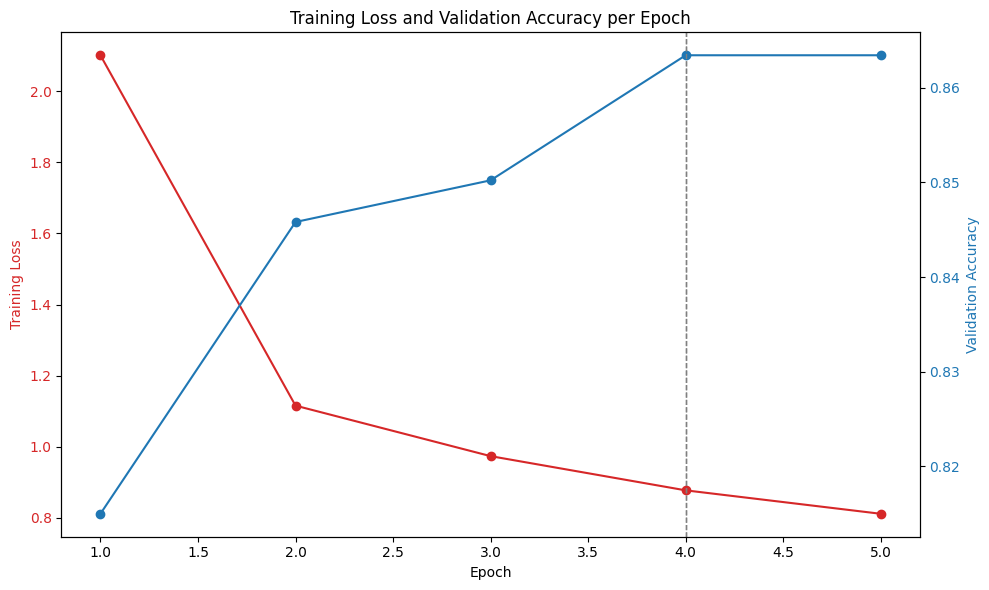

In [ ]:
# Extract the data from training_stats.
epochs = [entry['epoch'] for entry in training_stats]
train_loss = [entry['Training Loss'] for entry in training_stats]
valid_acc = [entry['Valid. Acc'] for entry in training_stats]

# Optional: Determine the best epoch based on validation accuracy.
best_epoch = epochs[valid_acc.index(max(valid_acc))]
print("Best Epoch:", best_epoch)

# Create a plot with two y-axes: one for Training Loss and one for Validation Accuracy.
fig, ax1 = plt.subplots(figsize=(10,6))

# Plot the Training Loss on the primary y-axis.
color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(epochs, train_loss, color=color, marker='o', label='Training Loss')
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis for Validation Accuracy.
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Validation Accuracy', color=color)
ax2.plot(epochs, valid_acc, color=color, marker='o', label='Validation Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and a legend.
plt.title('Training Loss and Validation Accuracy per Epoch')
fig.tight_layout()  # Ensure the layout fits the figure area

# Optionally, mark the best epoch on the plot with a vertical line
ax1.axvline(x=best_epoch, color='gray', linestyle='--', linewidth=1)
ax2.axvline(x=best_epoch, color='gray', linestyle='--', linewidth=1)

plt.show()